
Dataset Preview:
     Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913

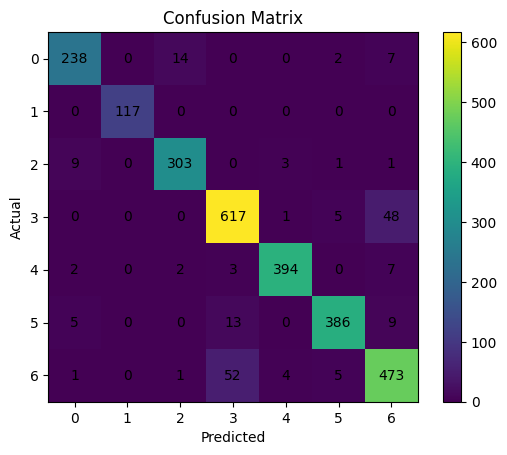

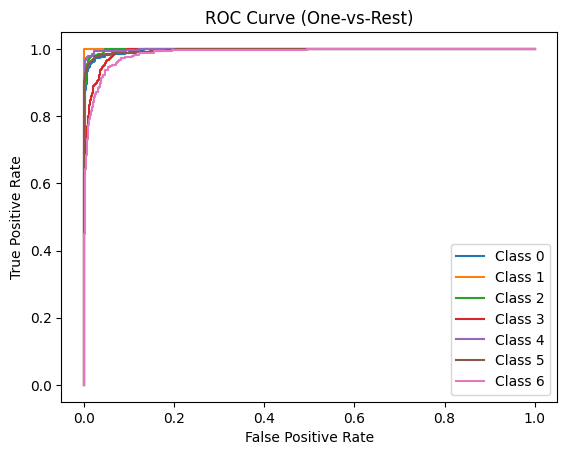

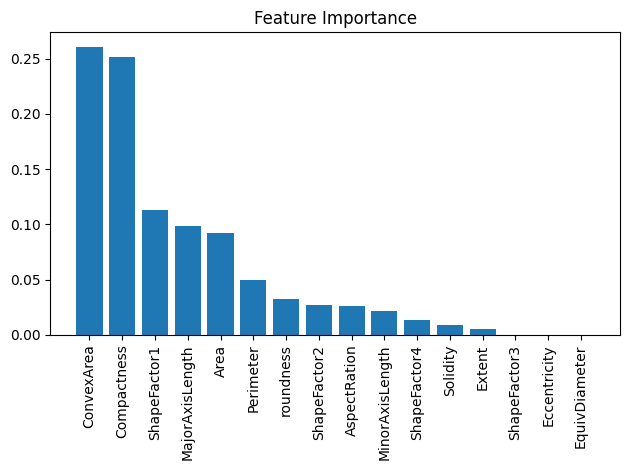

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from xgboost import XGBClassifier


#Step 1: Load Dataset
file_path = r"/content/drive/MyDrive/Untitled Folder/Dry_Bean_Dataset.xlsx"
df = pd.read_excel(file_path)

print("\nDataset Preview:\n", df.head())

# Step 2: Pre-processing

# Target column
target_column = input("\nEnter target column name: ")

# Handle missing values
df = df.fillna(df.mean(numeric_only=True))
df = df.fillna("Unknown")

# Encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Features and Target
X = df.drop(columns=[target_column])
y = df[target_column]

# Step 3: Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Model Training
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# Step 5: Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)  # For multiclass ROC, get probabilities for all classes

# Step 6: Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted') # Changed to 'weighted'
recall = recall_score(y_test, y_pred, average='weighted')      # Changed to 'weighted'
f1 = f1_score(y_test, y_pred, average='weighted')              # Changed to 'weighted'
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted') # Added multi_class and average for multiclass

print("\n===== Evaluation Metrics =====")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

# Step 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

# Step 8: ROC Curve
# For multiclass, plot one-vs-rest ROC curves
for i in range(y_prob.shape[1]):
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, i], pos_label=i)
    plt.plot(fpr, tpr, label=f'Class {i}')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

# Step 9: Feature Importance
importance = model.feature_importances_
features = X.columns

# Sort features
indices = np.argsort(importance)[::-1]

plt.figure()
plt.title("Feature Importance")
plt.bar(range(len(importance)), importance[indices])
plt.xticks(range(len(importance)), features[indices], rotation=90)
plt.tight_layout()
plt.show()

Dataset Shape: (11055, 32)
   id  having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
0   1                 -1           1                   1                 1   
1   2                  1           1                   1                 1   
2   3                  1           0                   1                 1   
3   4                  1           0                   1                 1   
4   5                  1           0                  -1                 1   

   double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  SSLfinal_State  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   Domain_registe

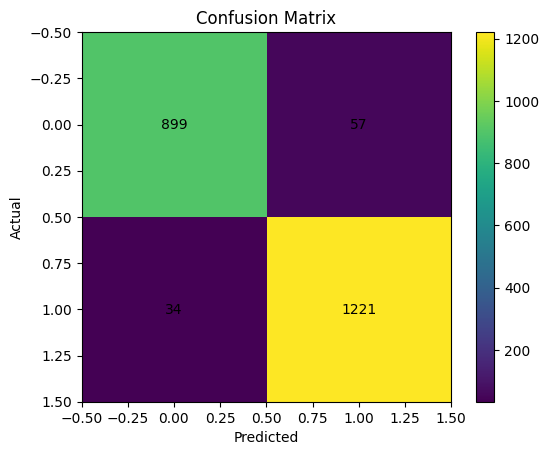

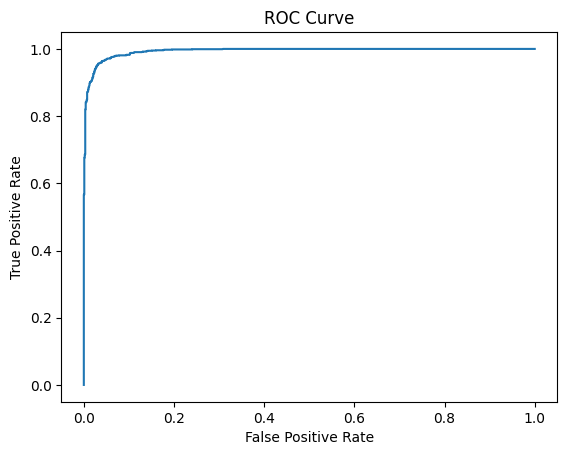

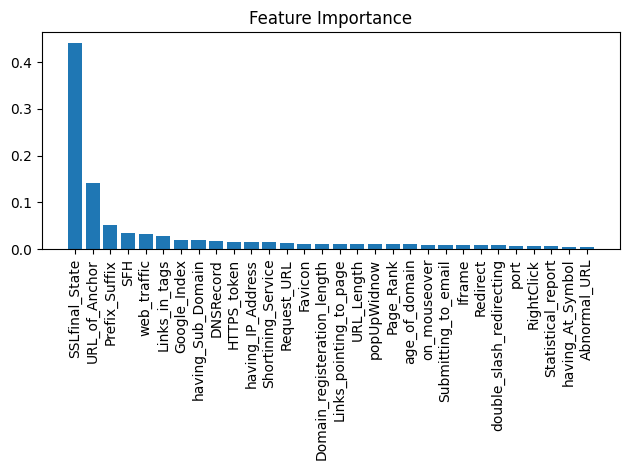

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from xgboost import XGBClassifier

# Step 1: Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Untitled Folder/csv_result-Training_Dataset[1].csv")

print("Dataset Shape:", df.shape)
print(df.head())

# Step 2: Pre-processing
# Drop unnecessary column
df = df.drop(columns=["id"])

# Convert target (-1,1) → (0,1)
df["Result"] = df["Result"].map({-1: 0, 1: 1})

# Split features and target
X = df.drop(columns=["Result"])
y = df["Result"]

# Step 3: Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Step 4: Model Training
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss'
)

model.fit(X_train, y_train)


# Step 5: Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Step 6: Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n===== Evaluation Metrics =====")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

# Step 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

# Step 8: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# Step 9: Feature Importance
importance = model.feature_importances_
features = X.columns

indices = np.argsort(importance)[::-1]

plt.figure()
plt.title("Feature Importance")
plt.bar(range(len(importance)), importance[indices])
plt.xticks(range(len(importance)), features[indices], rotation=90)
plt.tight_layout()
plt.show()